<a href="https://colab.research.google.com/github/yash-r04/colab_ml_marvel/blob/main/pcos_ensemble_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

decision tree to predict polycystic ovarian syndrome

dataset: https://www.kaggle.com/datasets/samikshadalvi/pcos-diagnosis-dataset/data

In [ ]:
!pip install graphviz pydot

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,mean_absolute_error, mean_squared_error, classification_report
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

[download pcos data from here](https://drive.google.com/file/d/1jJGDSO49ssH8ut_U27d2V-et23_0jKwZ/view?usp=sharing)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mode

pcos = "/content/pcos_dataset.csv"
df = pd.read_csv(pcos)

df.head()

,Age,BMI,Menstrual_Irregularity,Testosterone_Level(ng/dL),Antral_Follicle_Count,PCOS_Diagnosis
0,24,34.7,1,25.2,20,0
1,37,26.4,0,57.1,25,0
2,32,23.6,0,92.7,28,0
3,28,28.8,0,63.1,26,0
4,25,22.1,1,59.8,8,0


In [ ]:
print(df.isnull().sum())

Age                          0
BMI                          0
Menstrual_Irregularity       0
Testosterone_Level(ng/dL)    0
Antral_Follicle_Count        0
PCOS_Diagnosis               0
dtype: int64


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop(columns=['PCOS_Diagnosis'])
y = df['PCOS_Diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model1 = DecisionTreeClassifier(random_state=42)
model2 = SVC(probability=True, random_state=42)
model3 = LogisticRegression(random_state=42)

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

LogisticRegression(random_state=42)



---

#max voting

In [ ]:
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

final_pred = np.array([mode([p1, p2, p3]).mode if isinstance(mode([p1, p2, p3]).mode, np.ndarray) else mode([p1, p2, p3]).mode for p1, p2, p3 in zip(pred1, pred2, pred3)])

accuracy = accuracy_score(y_test, final_pred)
print("Majority Voting Accuracy:", accuracy)

Majority Voting Accuracy: 0.935




---

#Stacking

In [ ]:
train_pred1 = model1.predict(X_train)
train_pred2 = model2.predict(X_train)
train_pred3 = model3.predict(X_train)

test_pred1 = model1.predict(X_test)
test_pred2 = model2.predict(X_test)
test_pred3 = model3.predict(X_test)

# Stack predictions as new features
X_train_stack = np.column_stack((train_pred1, train_pred2, train_pred3))
X_test_stack = np.column_stack((test_pred1, test_pred2, test_pred3))

In [ ]:
meta_model = LogisticRegression()
meta_model.fit(X_train_stack, y_train)

# Make final predictions
final_pred = meta_model.predict(X_test_stack)

# Evaluate accuracy
accuracy = accuracy_score(y_test, final_pred)
print("Stacking Accuracy:", accuracy)

Stacking Accuracy: 0.995





---


#blending


In [ ]:
X_train_blend, X_val, y_train_blend, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
model1.fit(X_train_blend, y_train_blend)
model2.fit(X_train_blend, y_train_blend)
model3.fit(X_train_blend, y_train_blend)

LogisticRegression(random_state=42)

In [ ]:
val_pred1 = model1.predict(X_val)
val_pred2 = model2.predict(X_val)
val_pred3 = model3.predict(X_val)

# Stack predictions as new features
X_val_blend = np.column_stack((val_pred1, val_pred2, val_pred3))

In [ ]:
meta_model.fit(X_val_blend, y_val)

LogisticRegression()

In [ ]:
test_pred1 = model1.predict(X_test)
test_pred2 = model2.predict(X_test)
test_pred3 = model3.predict(X_test)

X_test_blend = np.column_stack((test_pred1, test_pred2, test_pred3))

final_pred_blend = meta_model.predict(X_test_blend)

# Evaluate accuracy
accuracy_blend = accuracy_score(y_test, final_pred_blend)
print("Blending Accuracy:", accuracy_blend)

Blending Accuracy: 0.995


In [ ]:
print(f"Stacking Accuracy: {accuracy}")
print(f"Blending Accuracy: {accuracy_blend}")

Stacking Accuracy: 0.995
Blending Accuracy: 0.995




---

#boosting

##GBM

In [ ]:
gbm_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbm_model.fit(X_train, y_train)

# Make predictions
y_pred = gbm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"GBM Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

GBM Accuracy: 0.9950
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       161
           1       1.00      0.97      0.99        39

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



##XGBM

In [ ]:
!pip install xgboost
import xgboost as xgb
from xgboost import XGBClassifier

In [ ]:
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

XGBoost Accuracy: 0.9950
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       161
           1       1.00      0.97      0.99        39

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200





---

#Bagging

##Random forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
X = df.drop(columns=['PCOS_Diagnosis'])  # Replace 'target' with actual target column name
y = df['PCOS_Diagnosis']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Model
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

# Display Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9900
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       161
           1       1.00      0.95      0.97        39

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200



In [ ]:
from sklearn.tree import export_graphviz
import pydot
tree = rf_model.estimators_[5]

# Get feature names
feature_list = list(X.columns)
tree = rf.estimators_[5]

# Get feature names
feature_list = list(X.columns)

In [ ]:
export_graphviz(
    tree,
    out_file="tree.dot",
    feature_names=feature_list,
    rounded=True,
    precision=1,
    filled=True  # Color the nodes based on class
)

# Convert DOT file to PNG
(graph,) = pydot.graph_from_dot_file("tree.dot")
graph.write_png("tree.png")

print("Tree visualization saved as tree.png!")

Tree visualization saved as tree.png!


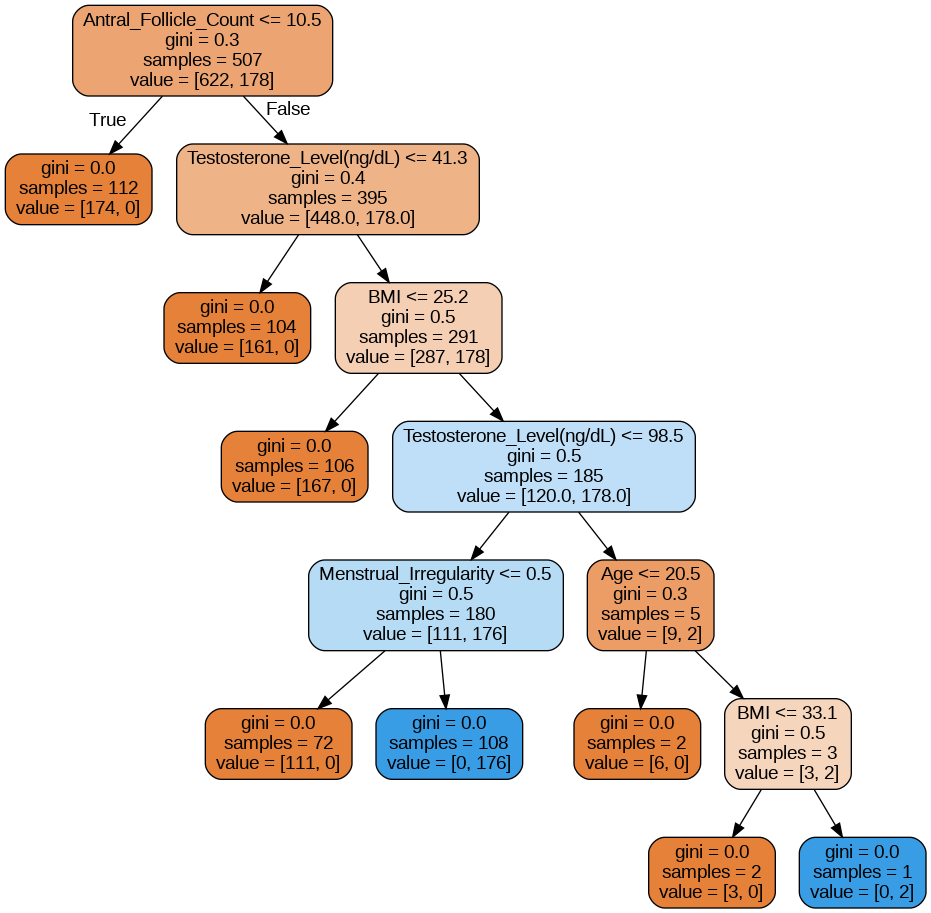

In [ ]:
from IPython.display import Image

# Display the image


Image(filename="tree.png")